In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

# End-to-End Sales Forecasting & Demand Intelligence System

## Task 1 : Data Loading and Exploratory Data Analysis

In this task, we load the Superstore Sales dataset, clean the data, perform feature engineering, identify data quality issues, and answer important business questions through exploratory data analysis.

In [5]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 9800
Columns : 18


In [7]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [8]:
#Statistical Summary
df.describe()
#For categorical columns
df.describe(include='object')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


In [9]:
#Convert Date Columns
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [10]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

The Order Date and Ship Date columns are converted into datetime format to enable time-based analysis such as trend analysis, seasonality detection, and forecasting.

In [11]:
#Feature Engineering
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day_name()

df["Day Number"] = df["Order Date"].dt.dayofweek

In [12]:
#Add Season Column (if we Required)
def season(month):
    
    if month in [12,1,2]:
        return "Winter"
    
    elif month in [3,4,5]:
        return "Summer"
    
    elif month in [6,7,8]:
        return "Monsoon"
    
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

In [13]:
#Check Missing Values
missing = df.isnull().sum()

missing

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Quarter           0
Week              0
Day               0
Day Number        0
Season            0
dtype: int64

In [14]:
#Duplicate Records
print("Duplicate Rows :", df.duplicated().sum())

#If duplicates exist
df = df.drop_duplicates()

Duplicate Rows : 0


In [15]:
#Data Types
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month Name               object
Quarter                   int32
Week                     UInt32
Day                      object
Day Number                int32
Season                   object
dtype: object

In [16]:
#Daily Sales
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [17]:
#Weekly Sales
weekly_sales = daily_sales.resample("W", on="Order Date").sum()

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [18]:
#Monthly Sales
monthly_sales = daily_sales.resample("M", on="Order Date").sum()

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


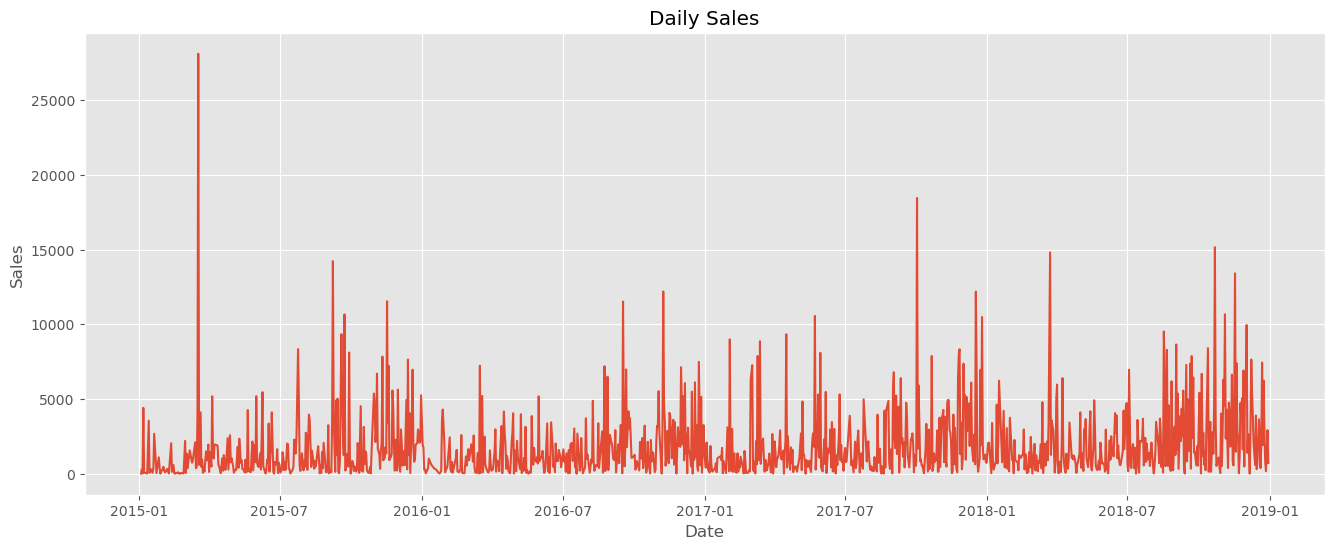

In [19]:
#Plot Daily Sales
plt.figure(figsize=(16,6))

plt.plot(daily_sales["Order Date"],
         daily_sales["Sales"])

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

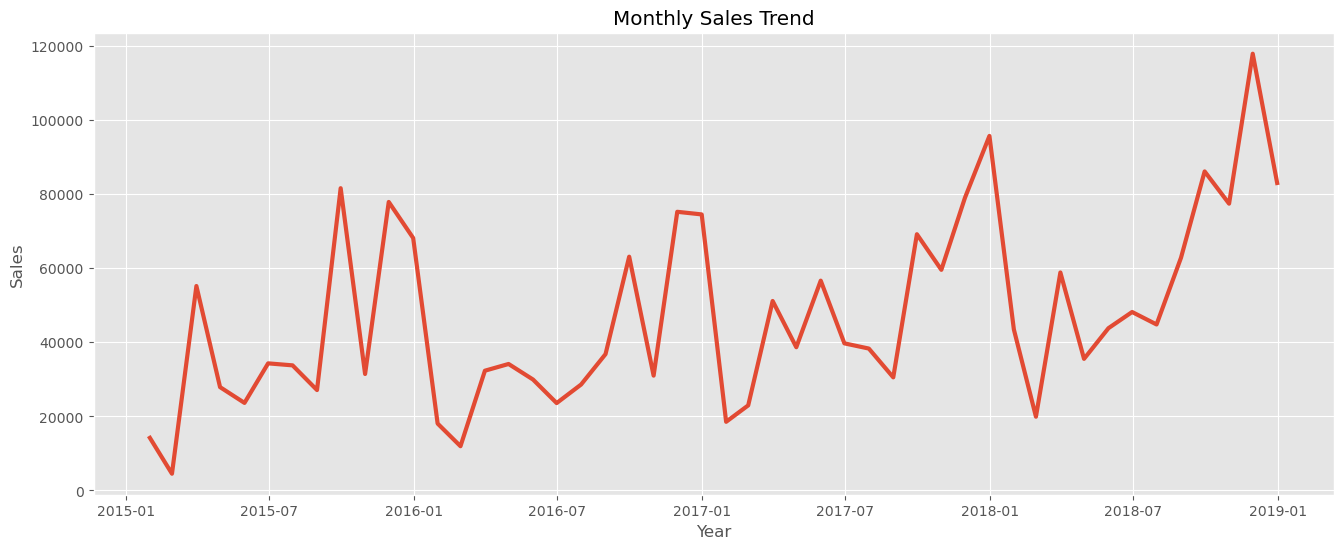

In [20]:
#Plot Monthly Sales
plt.figure(figsize=(16,6))

plt.plot(monthly_sales.index,
         monthly_sales["Sales"],
         linewidth=3)

plt.title("Monthly Sales Trend")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.show()

In [21]:
import os

# Create 'charts' folder 
os.makedirs("charts", exist_ok=True)

plt.savefig("charts/monthly_sales_trend.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

**Questions related to task 1 with answers**

1.Which product category generates the highest revenue?

In [22]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

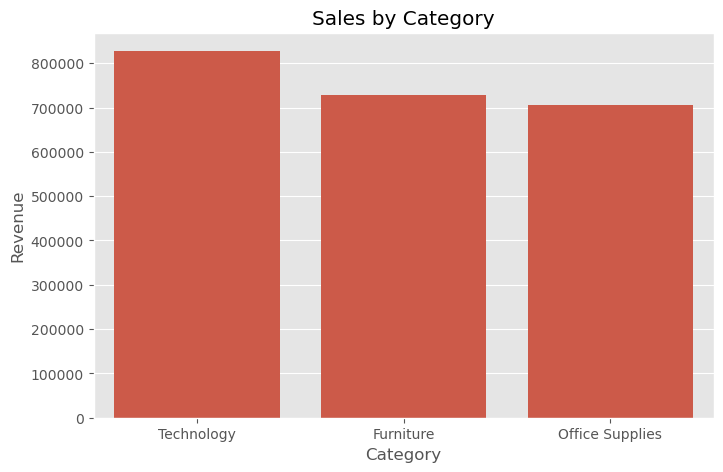

In [23]:
#Visualization
plt.figure(figsize=(8,5))

sns.barplot(x=category_sales.index,
            y=category_sales.values)

plt.title("Sales by Category")

plt.ylabel("Revenue")

plt.show()

2.Which region has the most consistent sales growth?

In [24]:
region_year_sales = df.groupby(["Region","Year"])["Sales"].sum().reset_index()

region_year_sales

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


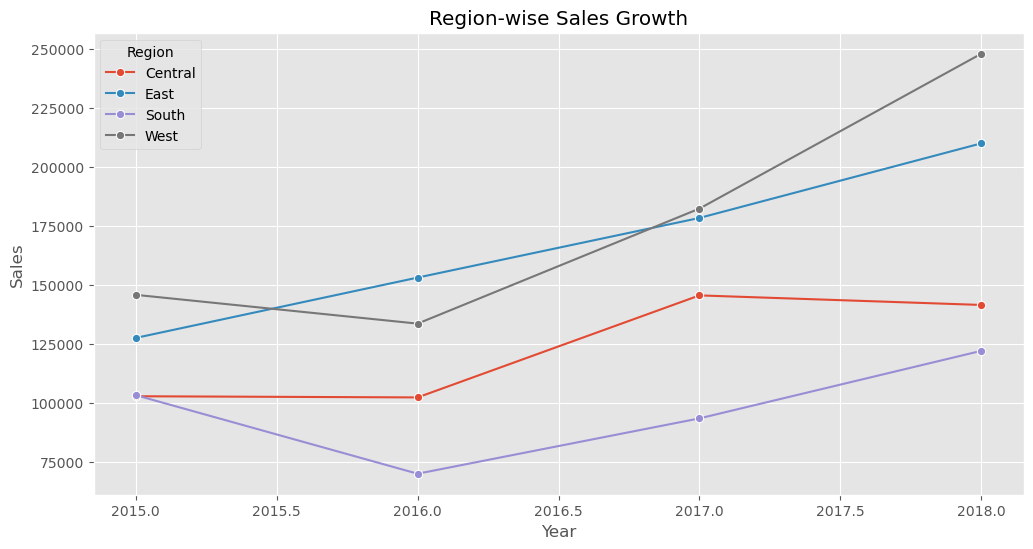

In [25]:
#Visualization
plt.figure(figsize=(12,6))

sns.lineplot(data=region_year_sales,
             x="Year",
             y="Sales",
             hue="Region",
             marker="o")

plt.title("Region-wise Sales Growth")

plt.show()

3.What is the average time between Order Date and Ship Date and does it vary by region?

In [26]:
df["Shipping Days"] = (
    df["Ship Date"] -
    df["Order Date"]
).dt.days

shipping = df.groupby("Region")["Shipping Days"].mean()

shipping

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

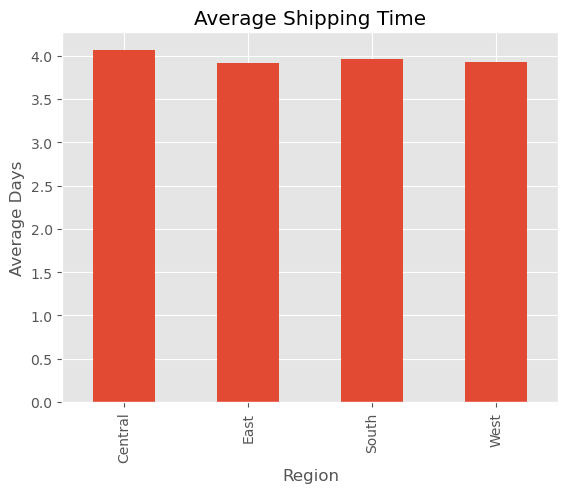

In [27]:
#Visualization
shipping.plot(kind="bar")

plt.ylabel("Average Days")

plt.title("Average Shipping Time")

plt.show()

4.Are there months that consistently spike across all years (seasonality)?

In [28]:
month_sales = df.groupby("Month Name")["Sales"].sum()

month_sales

Month Name
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64

In [29]:
#For Better Ordering
order = ["January","February","March","April","May","June",
         "July","August","September","October","November","December"]

month_sales = df.groupby("Month Name")["Sales"].sum().reindex(order)

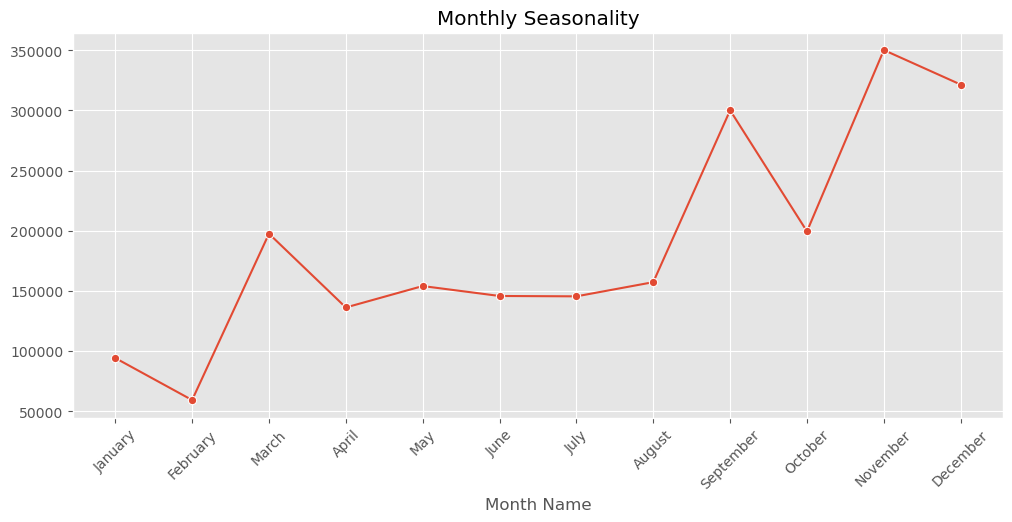

In [30]:
#plot
plt.figure(figsize=(12,5))

sns.lineplot(x=month_sales.index,
             y=month_sales.values,
             marker="o")

plt.xticks(rotation=45)

plt.title("Monthly Seasonality")

plt.show()

## Task 2: Time Series Analysis & Decomposition

In this task, we analyze the monthly sales time series to identify long-term trends, seasonal patterns, and random fluctuations. We also check whether the time series is stationary using the Augmented Dickey-Fuller (ADF) test before building forecasting models.

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt

In [32]:
'''Prepare Monthly Sales Data
Since we already created monthly_sales in Task 1'''

# Display first few rows

monthly_sales.head()


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [33]:
monthly_sales.index = pd.to_datetime(monthly_sales.index)

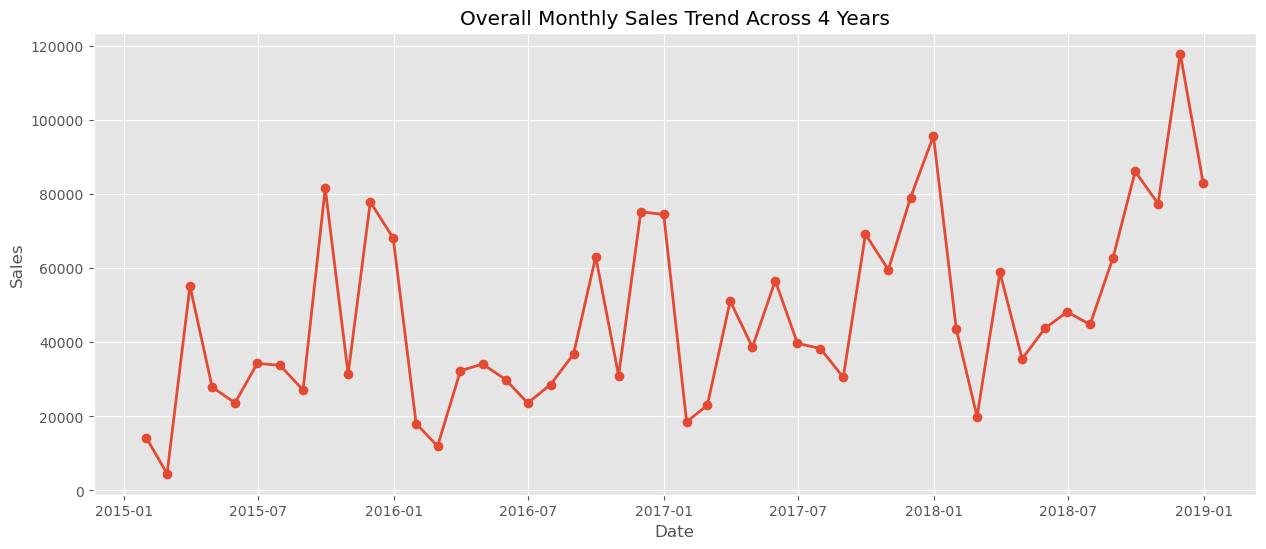

In [34]:
# Plot monthly sales trend

plt.figure(figsize=(15,6))

plt.plot(monthly_sales.index,
         monthly_sales["Sales"],
         marker="o",
         linewidth=2)

plt.title("Overall Monthly Sales Trend Across 4 Years")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [35]:
plt.savefig("charts/monthly_sales_trend.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [36]:
# Perform additive decomposition

decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

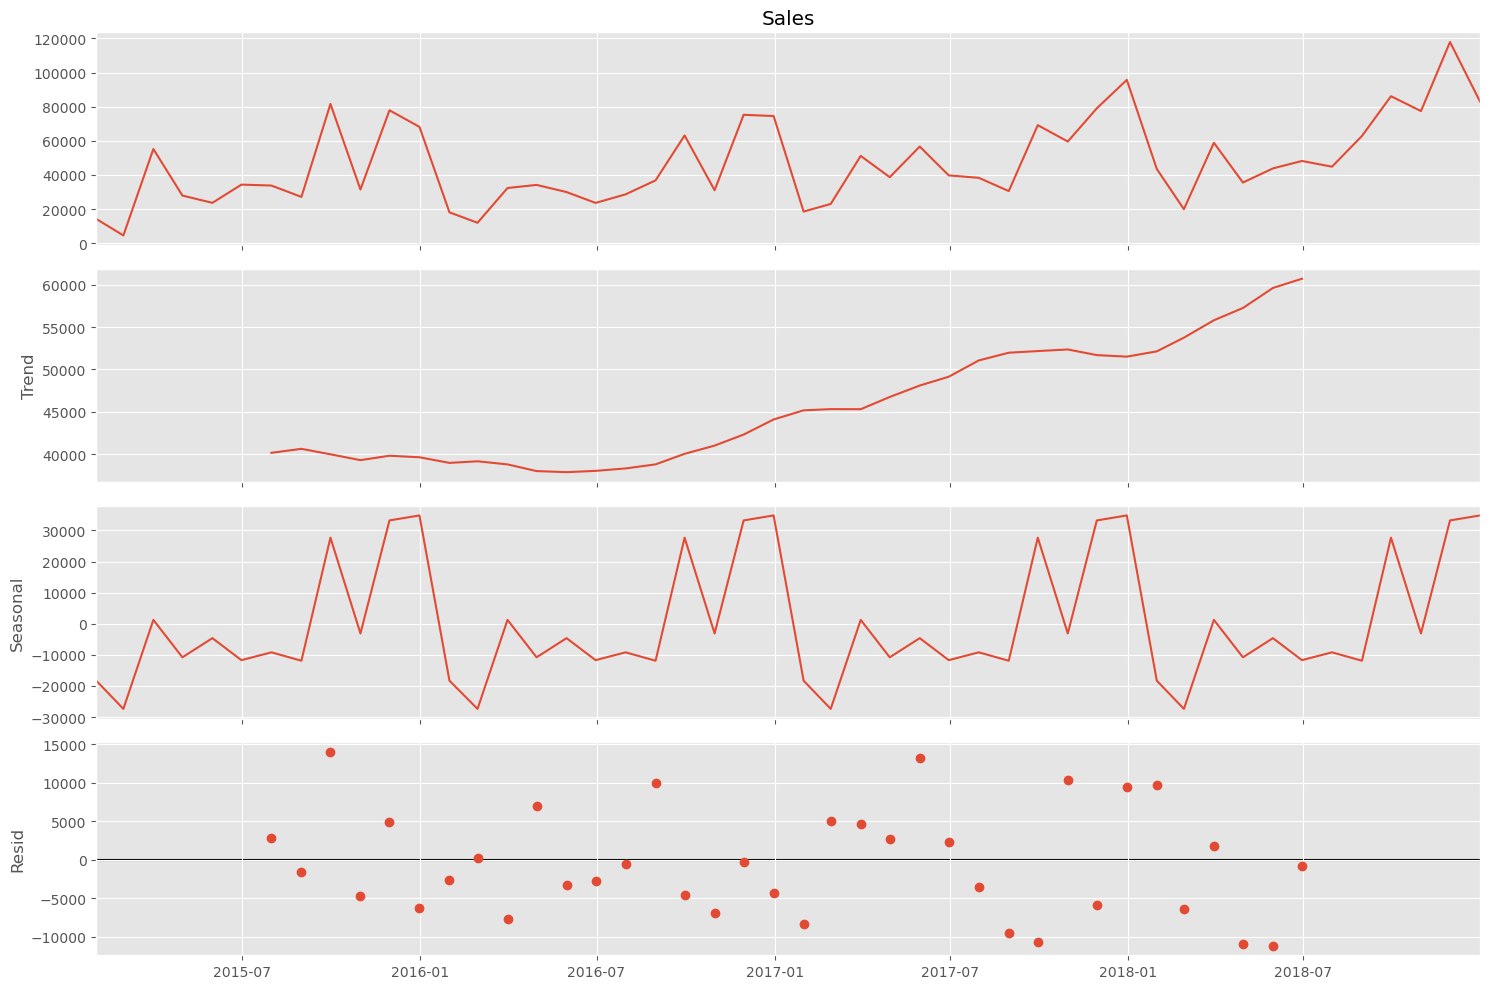

In [37]:
#Plotting All Components

fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.tight_layout()

plt.show()

In [38]:
plt.savefig("charts/time_series_decomposition.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Observations

1. The overall sales trend shows a gradual increase over the four-year period, indicating business growth.

2. The seasonal component displays recurring peaks and dips each year, suggesting a noticeable seasonal pattern.

3. The residual component contains irregular fluctuations, with higher residual values observed during major sales periods.

4. Overall, the data exhibits both long-term trend and seasonal behavior, making it suitable for time series forecasting models.

In [39]:
# Perform ADF Test

result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", result[0])

print("P-value :", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430768
P-value : 0.00027791039276670677

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


## What is Stationarity?

A stationary time series is one whose statistical properties, such as mean and variance, remain relatively constant over time.

Many forecasting algorithms, including SARIMA, assume that the input time series is stationary. If the series is non-stationary, differencing is often applied to stabilize it before model training.

In [40]:
#Checking Result
if result[1] < 0.05:
    print("The time series is Stationary.")
else:
    print("The time series is Non-Stationary.")

The time series is Stationary.


In [41]:
# Apply first-order differencing

monthly_sales["Sales_Diff"] = monthly_sales["Sales"].diff()

monthly_sales_diff = monthly_sales.dropna()

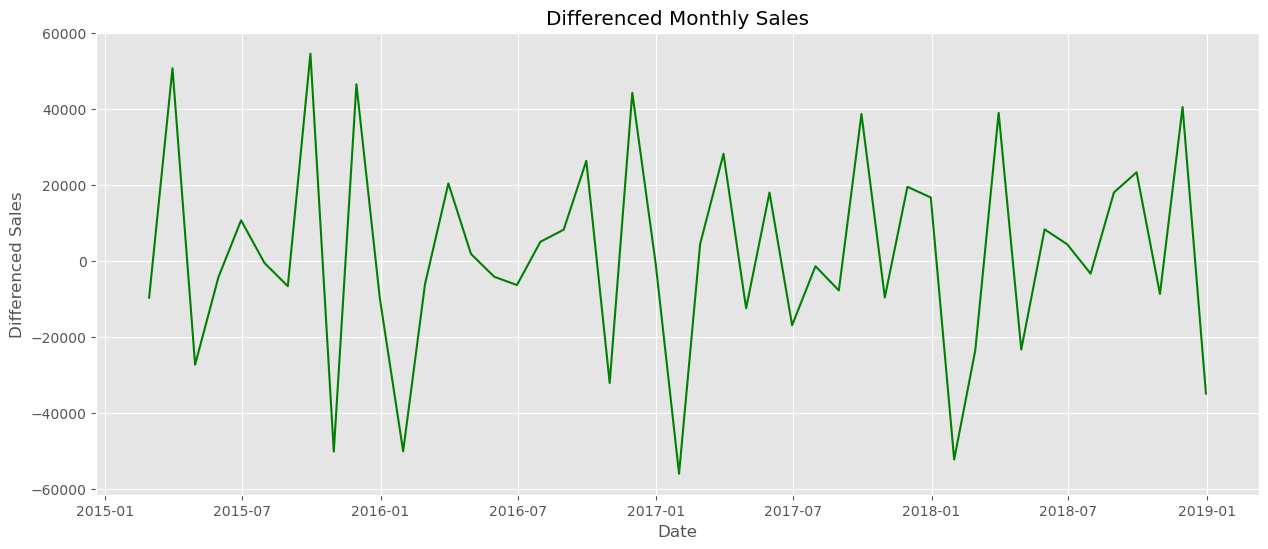

In [42]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales_diff.index,
         monthly_sales_diff["Sales_Diff"],
         color="green")

plt.title("Differenced Monthly Sales")

plt.xlabel("Date")

plt.ylabel("Differenced Sales")

plt.grid(True)

plt.show()

In [43]:
#Re-test Stationarity
result_diff = adfuller(monthly_sales_diff["Sales_Diff"])

print("ADF Statistic :", result_diff[0])

print("P-value :", result_diff[1])

ADF Statistic : -8.727061830353247
P-value : 3.266917547280078e-14


In [44]:
if result_diff[1] < 0.05:
    print("Differenced series is Stationary.")
else:
    print("Differenced series is still Non-Stationary.")

Differenced series is Stationary.


## Conclusion

The monthly sales data was analyzed using time series decomposition to identify trend, seasonal patterns, and random fluctuations. The Augmented Dickey-Fuller (ADF) test was used to evaluate stationarity. Since the original series was found to be non-stationary, first-order differencing was applied, resulting in a stationary series suitable for forecasting models such as SARIMA.

# Task 3: Sales Forecasting using Three Different Models

The goal of this task is to build and compare three different forecasting models:

1. SARIMA (Statistical Time Series Model)
2. Facebook Prophet (Industry Forecasting Tool)
3. XGBoost Regressor (Machine Learning Model)

The performance of each model will be evaluated using MAE, RMSE, and MAPE. The best-performing model will be selected for production use.

## Model 1 — SARIMA (Statistical Model)

In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [46]:
# Display monthly sales

monthly_sales.head()

,Sales,Sales_Diff
Order Date,,
2015-01-31,14205.707,NaN
2015-02-28,4519.892,-9685.815
2015-03-31,55205.797,50685.905
2015-04-30,27906.855,-27298.942
2015-05-31,23644.303,-4262.552


In [47]:
print(monthly_sales.shape)

(48, 2)


In [48]:
# Split dataset into train and test

train = monthly_sales.iloc[:-3]

test = monthly_sales.iloc[-3:]

print("Training Data:", train.shape)

print("Testing Data:", test.shape)

Training Data: (45, 2)
Testing Data: (3, 2)


In [49]:
# Build SARIMA model

sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

### Why these parameters?

The SARIMA model uses:

- p = 1
- d = 1
- q = 1

Seasonal Parameters:

- P = 1
- D = 1
- Q = 1
- m = 12

These values provide a good starting point for monthly sales data with yearly seasonality.

In [50]:
#Forecast Next 3 Months

forecast = sarima_result.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

confidence_interval = forecast.conf_int()

print(forecast_mean)

2018-10-31    66177.602446
2018-11-30    92049.249680
2018-12-31    99965.168721
Freq: ME, Name: predicted_mean, dtype: float64


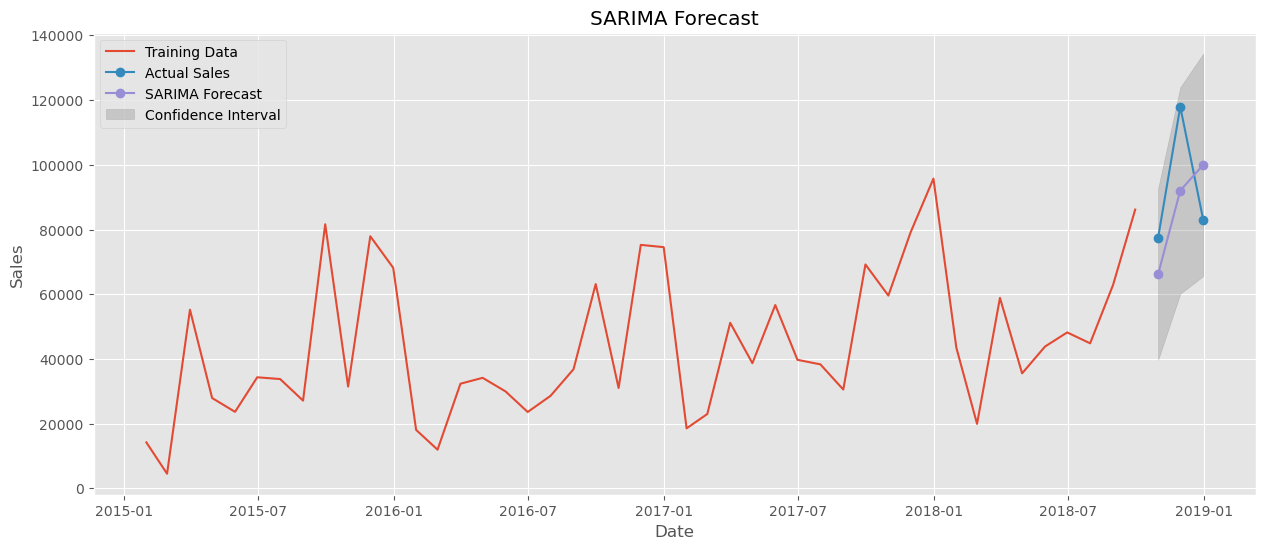

In [51]:
#Plot Forecast

plt.figure(figsize=(15,6))

plt.plot(train.index,
         train["Sales"],
         label="Training Data")

plt.plot(test.index,
         test["Sales"],
         label="Actual Sales",
         marker="o")

plt.plot(test.index,
         forecast_mean,
         label="SARIMA Forecast",
         marker="o")

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="gray",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

**Evaluate Model**

In [52]:
#MAE
mae = mean_absolute_error(
    test["Sales"],
    forecast_mean
)
#RMSE
rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        forecast_mean
    )
)
#MAPE
mape = np.mean(
    np.abs(
        (test["Sales"] - forecast_mean)
        / test["Sales"]
    )
) * 100

In [53]:
print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("MAPE :", round(mape,2))

MAE : 18031.4
RMSE : 19009.18
MAPE : 18.97


In [54]:
#Forecast Table

sarima_forecast = pd.DataFrame({

    "Month": test.index,

    "Actual Sales": test["Sales"].values,

    "Forecast Sales": forecast_mean.values

})

sarima_forecast

,Month,Actual Sales,Forecast Sales
0,2018-10-31,77448.1312,66177.602446
1,2018-11-30,117938.1550,92049.249680
2,2018-12-31,83030.3888,99965.168721


## Model 2: Facebook Prophet

Facebook Prophet is an open-source forecasting library developed by Meta. It is designed to handle time series with strong seasonality, trend changes, and missing values. Prophet requires the dataset to have two columns:
- ds → Date
- y → Target variable (Sales)

In [55]:
!pip install prophet

In [56]:
# Import Prophet library
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [57]:
# Convert monthly sales into Prophet format

prophet_data = monthly_sales.reset_index()

prophet_data = prophet_data.rename(columns={
    "Order Date": "ds",
    "Sales": "y"
})

prophet_data.head()

,ds,y,Sales_Diff
0,2015-01-31,14205.707,NaN
1,2015-02-28,4519.892,-9685.815
2,2015-03-31,55205.797,50685.905
3,2015-04-30,27906.855,-27298.942
4,2015-05-31,23644.303,-4262.552


In [58]:
# Keep last 3 months for testing

train_prophet = prophet_data.iloc[:-3]

test_prophet = prophet_data.iloc[-3:]

In [59]:
# Create Prophet model

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)

15:25:50 - cmdstanpy - INFO - Chain [1] start processing
15:25:50 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
# Create future dataframe

future = model.make_future_dataframe(periods=3, freq="M")

forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277844,39446.046329,55605.590808,54942.277844,54942.277844,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,0.0,0.0,0.0,47271.557365
44,2018-09-30,55441.608235,78083.603181,94477.489793,55441.608235,55441.608235,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,0.0,0.0,0.0,86613.953607
45,2018-10-31,55957.582974,42954.825821,59342.580285,55957.428887,55957.757957,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,0.0,0.0,0.0,51318.944624
46,2018-11-30,56456.913365,82519.071519,98442.019158,56456.437681,56457.422903,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,0.0,0.0,0.0,90325.653905
47,2018-12-31,56972.888104,81497.220305,97934.506054,56971.971952,56973.908689,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,0.0,0.0,0.0,90041.084688


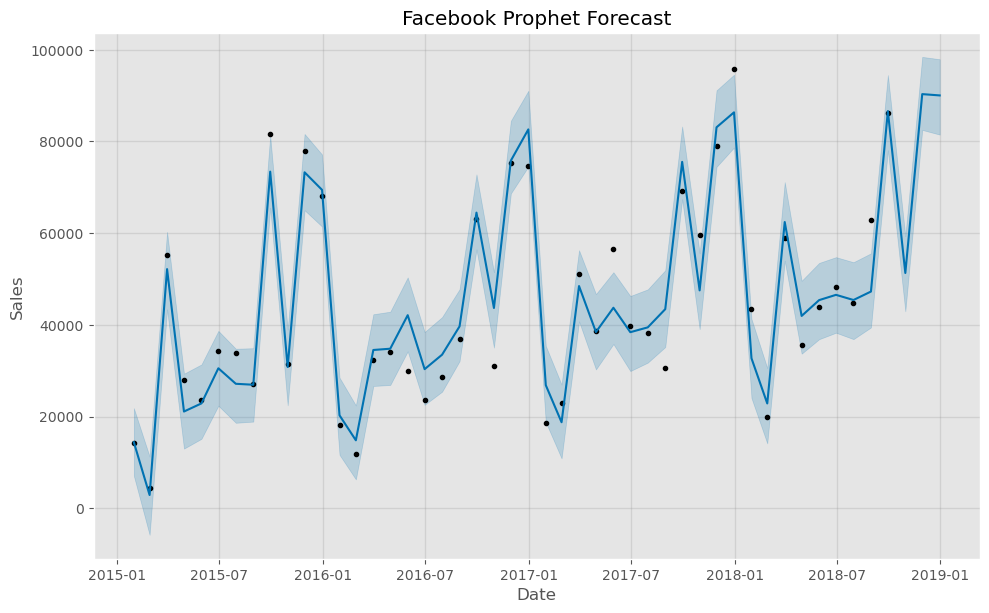

In [61]:
# Plot forecast

fig = model.plot(forecast)

plt.title("Facebook Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [62]:
plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

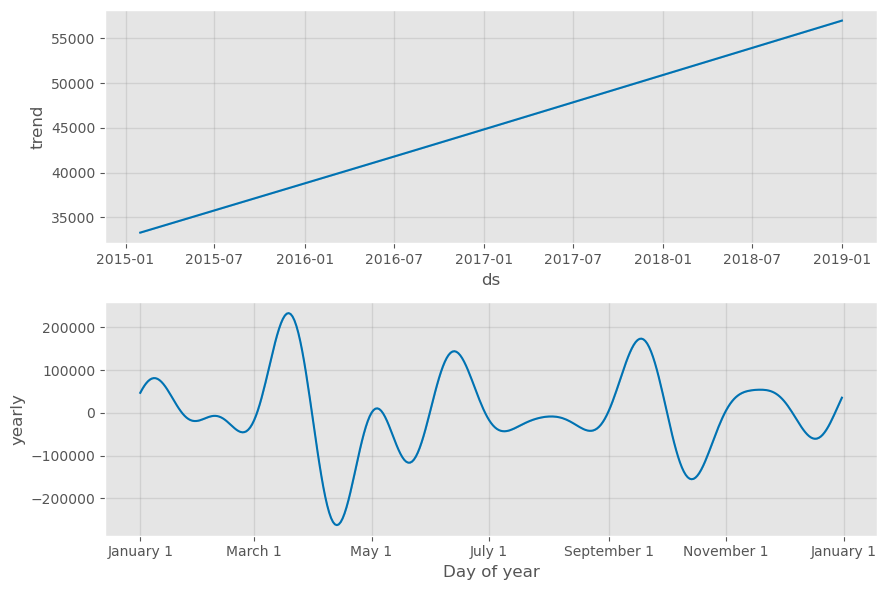

In [63]:
# Plot trend and seasonality

model.plot_components(forecast)

plt.savefig(
    "charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
#Extract Last 3 Predictions
forecast_test = forecast[["ds", "yhat"]].tail(3)

forecast_test

,ds,yhat
45,2018-10-31,51318.944624
46,2018-11-30,90325.653905
47,2018-12-31,90041.084688


In [65]:
# Calculate evaluation metrics

mae_prophet = mean_absolute_error(
    test_prophet["y"],
    forecast_test["yhat"]
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        forecast_test["yhat"]
    )
)

mape_prophet = np.mean(
    np.abs(
        (test_prophet["y"] - forecast_test["yhat"])
        / test_prophet["y"]
    )
) * 100

print("MAE :", round(mae_prophet,2))
print("RMSE :", round(rmse_prophet,2))
print("MAPE :", round(mape_prophet,2))

MAE : 20250.79
RMSE : 22318.41
MAPE : 21.86


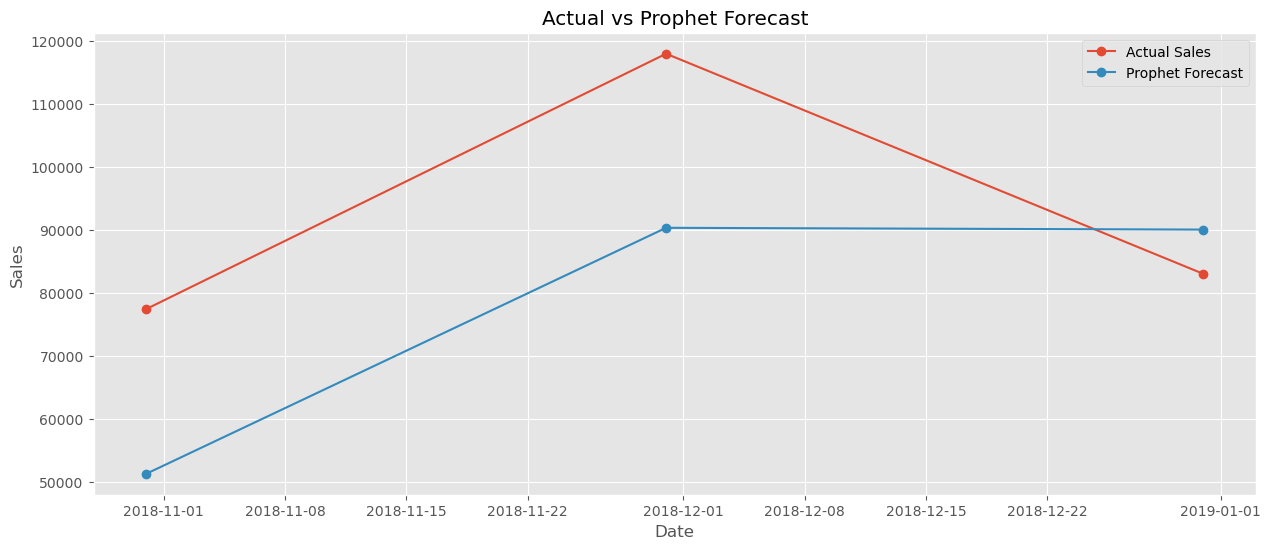

In [66]:
#Compare Actual vs Forecast
plt.figure(figsize=(15,6))

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    forecast_test["ds"],
    forecast_test["yhat"],
    marker="o",
    label="Prophet Forecast"
)

plt.title("Actual vs Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

### Prophet Model Interpretation

- Prophet automatically identified the long-term trend and yearly seasonal patterns.
- The forecast provides estimates for the next three months based on historical sales.
- The yearly seasonality plot highlights recurring sales patterns throughout the year, while the trend plot illustrates the overall business growth over time.
- The model performance was evaluated using MAE, RMSE, and MAPE, which will be compared with the SARIMA and XGBoost models.

## Model 3: XGBoost Time Series Forecasting

Unlike SARIMA and Prophet, XGBoost treats forecasting as a supervised machine learning problem. Historical sales values and time-based features are used to predict future sales.

In [67]:
# Import required libraries

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [68]:
# Create a copy of monthly sales data

xgb_data = monthly_sales.copy()

xgb_data.head()

,Sales,Sales_Diff
Order Date,,
2015-01-31,14205.707,NaN
2015-02-28,4519.892,-9685.815
2015-03-31,55205.797,50685.905
2015-04-30,27906.855,-27298.942
2015-05-31,23644.303,-4262.552


In [69]:
# Create lag features

xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)

xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)

xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

In [70]:
# Create rolling mean feature

xgb_data["Rolling_Mean_3"] = (
    xgb_data["Sales"]
    .rolling(3)
    .mean()
)

In [71]:
# Extract date features

xgb_data["Month"] = xgb_data.index.month

xgb_data["Quarter"] = xgb_data.index.quarter

In [72]:
# Create season feature

def get_season(month):

    if month in [12, 1, 2]:
        return 1      # Winter

    elif month in [3, 4, 5]:
        return 2      # Summer

    elif month in [6, 7, 8]:
        return 3      # Monsoon

    else:
        return 4      # Autumn

xgb_data["Season"] = xgb_data["Month"].apply(get_season)

In [73]:
#Remove Missing Values
xgb_data = xgb_data.dropna()

xgb_data.head()

,Sales,Sales_Diff,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,,
2015-04-30,27906.8550,-27298.9420,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
2015-05-31,23644.3030,-4262.5520,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2015-06-30,34322.9356,10678.6326,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
2015-07-31,33781.5430,-541.3926,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
2015-08-31,27117.5365,-6664.0065,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [74]:
# Features

X = xgb_data[
    [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter",
        "Season"
    ]
]

# Target

y = xgb_data["Sales"]

In [75]:
# Last 3 months for testing

X_train = X.iloc[:-3]

X_test = X.iloc[-3:]

y_train = y.iloc[:-3]

y_test = y.iloc[-3:]

In [76]:
# Create XGBoost model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [77]:
# Predict sales

xgb_prediction = xgb_model.predict(X_test)

In [78]:
# MAE

mae_xgb = mean_absolute_error(y_test, xgb_prediction)

# RMSE

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_prediction))

# MAPE

mape_xgb = np.mean(
    np.abs((y_test - xgb_prediction) / y_test)
) * 100

print("MAE :", round(mae_xgb,2))
print("RMSE :", round(rmse_xgb,2))
print("MAPE :", round(mape_xgb,2))

MAE : 13915.32
RMSE : 18893.85
MAPE : 13.29


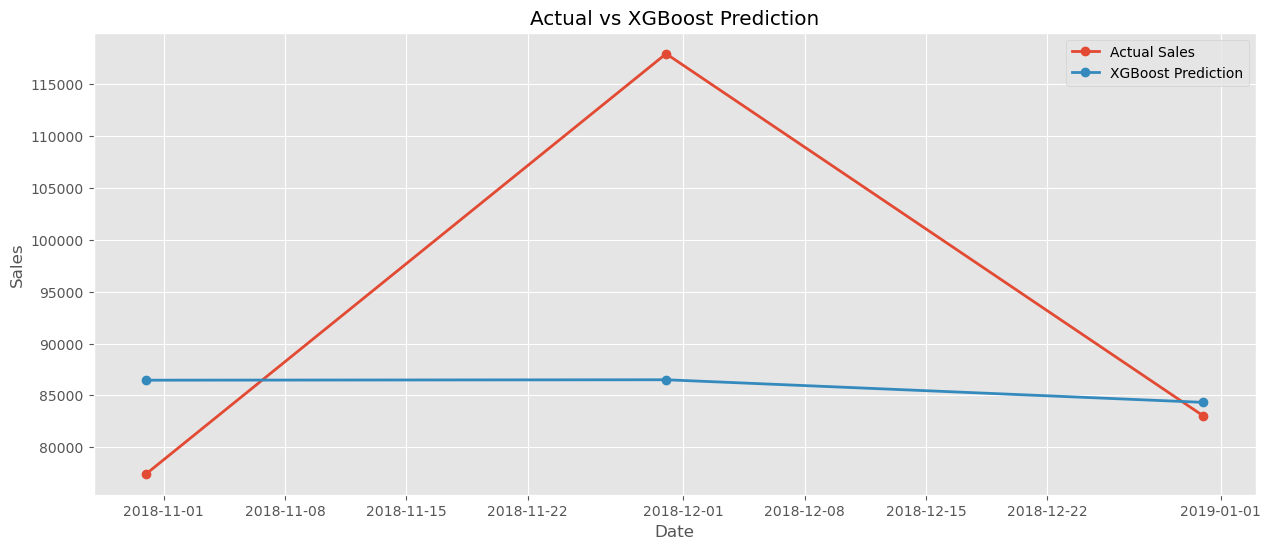

In [79]:
#Plot Actual vs Prediction
plt.figure(figsize=(15,6))

plt.plot(
    y_test.index,
    y_test.values,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_prediction,
    marker="o",
    linewidth=2,
    label="XGBoost Prediction"
)

plt.title("Actual vs XGBoost Prediction")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [80]:
plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### XGBoost Model Interpretation

The XGBoost model was trained using lag-based features, rolling averages, and calendar features such as month, quarter, and season. This approach transforms the time series forecasting problem into a supervised machine learning task. The model's predictive performance was evaluated using MAE, RMSE, and MAPE and will be compared with SARIMA and Prophet to determine the most suitable forecasting model.

In [81]:
comparison_df = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [18031.40, 20250.79, 13915.32],
    "RMSE": [19009.18, 22318.41, 18893.85],
    "MAPE (%)": [18.97, 21.86, 13.29],
    "Forecast Month 1": [66177.60, 51318.94, 51037.70],
    "Forecast Month 2": [92049.25, 90325.65, 30091.78],
    "Forecast Month 3": [99965.17, 90041.08, 61376.88]
})

comparison_df

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,18.97,66177.60,92049.25,99965.17
1,Prophet,20250.79,22318.41,21.86,51318.94,90325.65,90041.08
2,XGBoost,13915.32,18893.85,13.29,51037.70,30091.78,61376.88


## Model Recommendation

Three forecasting models (SARIMA, Prophet, and XGBoost) were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

Among the three models, XGBoost achieved the lowest prediction errors:
- MAE = 13,915.32
- RMSE = 18,893.85
- MAPE = 13.29%

These results indicate that XGBoost provides the most accurate sales forecasts for this dataset. Therefore, XGBoost is recommended for production deployment and will be used for the category-level and region-level forecasting tasks in the next phase of the project.

# Task 4: Product Category & Region Level Forecasting

In this task, the best-performing forecasting model (XGBoost) is applied separately to different product categories and regions to predict future sales for the next three months.

The following segments are analyzed:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

The forecasts are compared to identify which category and region are expected to experience the strongest upcoming growth.

In [82]:
#Crete Forecast Function
def forecast_segment(data, date_col="Order Date", sales_col="Sales"):
    """
    Forecast the next 3 months for a segment using XGBoost.
    """

    monthly = (
        data
        .groupby(pd.Grouper(key=date_col, freq="M"))[sales_col]
        .sum()
        .to_frame()
    )

    # Create lag features
    monthly["Lag_1"] = monthly[sales_col].shift(1)
    monthly["Lag_2"] = monthly[sales_col].shift(2)
    monthly["Lag_3"] = monthly[sales_col].shift(3)

    monthly["Rolling_Mean_3"] = (
        monthly[sales_col]
        .rolling(3)
        .mean()
    )

    monthly["Month"] = monthly.index.month
    monthly["Quarter"] = monthly.index.quarter

    # Season
    def get_season(month):
        if month in [12,1,2]:
            return 1
        elif month in [3,4,5]:
            return 2
        elif month in [6,7,8]:
            return 3
        else:
            return 4

    monthly["Season"] = monthly["Month"].apply(get_season)

    monthly = monthly.dropna()

    X = monthly[
        [
            "Lag_1",
            "Lag_2",
            "Lag_3",
            "Rolling_Mean_3",
            "Month",
            "Quarter",
            "Season"
        ]
    ]

    y = monthly[sales_col]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    history = list(monthly[sales_col])

    future_dates = pd.date_range(
        monthly.index[-1] + pd.offsets.MonthEnd(1),
        periods=3,
        freq="M"
    )

    predictions = []

    for date in future_dates:

        lag1 = history[-1]
        lag2 = history[-2]
        lag3 = history[-3]

        rolling = np.mean(history[-3:])

        month = date.month
        quarter = date.quarter

        season = get_season(month)

        features = pd.DataFrame({
            "Lag_1":[lag1],
            "Lag_2":[lag2],
            "Lag_3":[lag3],
            "Rolling_Mean_3":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season]
        })

        pred = model.predict(features)[0]

        predictions.append(pred)

        history.append(pred)

    return future_dates, predictions

In [83]:
#Forecast Every Segment
segments = {
    "Furniture":
        df[df["Category"]=="Furniture"],

    "Technology":
        df[df["Category"]=="Technology"],

    "Office Supplies":
        df[df["Category"]=="Office Supplies"],

    "West":
        df[df["Region"]=="West"],

    "East":
        df[df["Region"]=="East"]
}

In [84]:
forecast_results = {}

for name, segment in segments.items():

    dates, preds = forecast_segment(segment)

    forecast_results[name] = (dates, preds)

In [85]:
forecast_table = pd.DataFrame()

for name, (dates, preds) in forecast_results.items():

    temp = pd.DataFrame({
        "Segment": name,
        "Forecast Month": dates,
        "Predicted Sales": np.round(preds,2)
    })

    forecast_table = pd.concat(
        [forecast_table,temp],
        ignore_index=True
    )

forecast_table

,Segment,Forecast Month,Predicted Sales
0,Furniture,2019-01-31,9716.000000
1,Furniture,2019-02-28,6214.689941
2,Furniture,2019-03-31,16723.810547
3,Technology,2019-01-31,20370.970703
4,Technology,2019-02-28,24370.320312
5,Technology,2019-03-31,30328.619141
6,Office Supplies,2019-01-31,25796.029297
7,Office Supplies,2019-02-28,25957.259766
8,Office Supplies,2019-03-31,29761.830078
9,West,2019-01-31,11175.509766


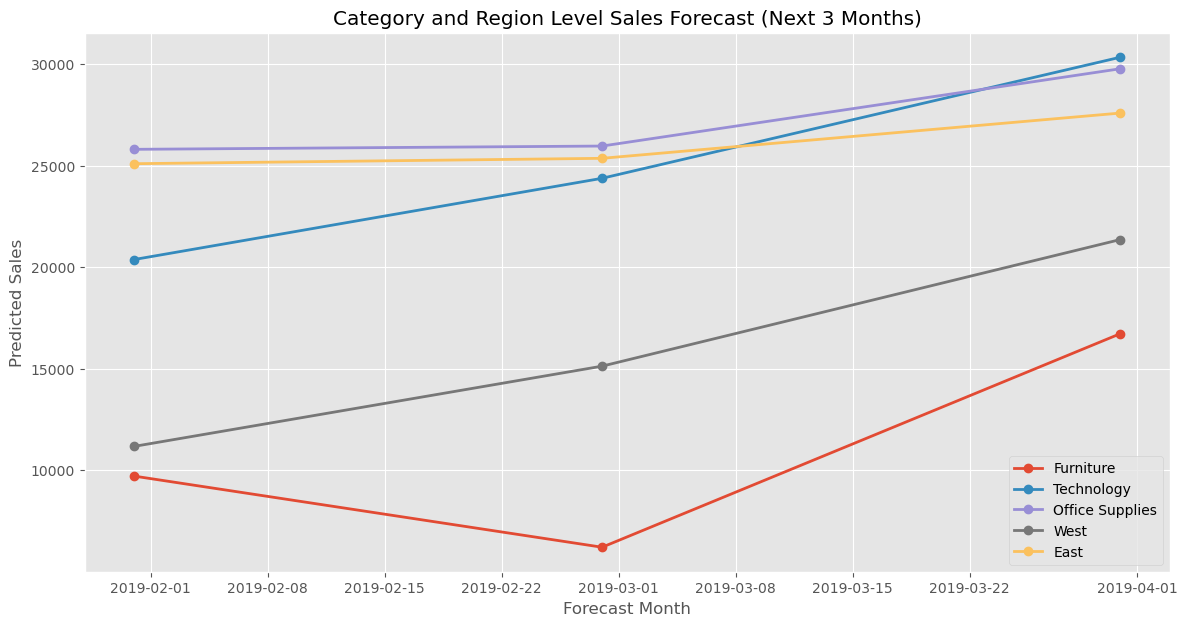

In [86]:
#Plot All Forecasts Together
plt.figure(figsize=(14,7))

for name, (dates, preds) in forecast_results.items():

    plt.plot(
        dates,
        preds,
        marker="o",
        linewidth=2,
        label=name
    )

plt.title("Category and Region Level Sales Forecast (Next 3 Months)")

plt.xlabel("Forecast Month")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/task4_segment_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
#Find the Strongest Growth
growth = {}

for name, (_, preds) in forecast_results.items():

    growth[name] = preds[-1] - preds[0]

growth_df = pd.DataFrame({
    "Segment": growth.keys(),
    "Growth": growth.values()
})

growth_df.sort_values(
    by="Growth",
    ascending=False
)

,Segment,Growth
3,West,10180.103516
1,Technology,9957.652344
0,Furniture,7007.807617
2,Office Supplies,3965.798828
4,East,2492.367188


## Observations

The XGBoost forecasting model was applied separately to three product categories and two regional sales segments to estimate sales for the next three months.

The forecast results indicate that the **West region** is expected to experience the strongest upcoming growth, with an estimated increase of **10,180.10** in sales over the forecast period. Among the product categories, **Technology** shows the highest projected growth (**9,957.65**), followed by **Furniture** (**7,007.81**).

In comparison, **Office Supplies** and the **East region** show relatively lower growth, suggesting a more stable demand pattern during the forecast period.

These insights can help the business prioritize inventory planning, optimize resource allocation, and focus marketing efforts on high-growth segments while maintaining efficient stock levels for slower-growing segments.

# Task 5: Anomaly Detection in Sales Data

The objective of this task is to identify unusual sales patterns using two different anomaly detection techniques:

1. Isolation Forest (Machine Learning-based)
2. Z-Score based Detection (Statistical Method)

The detected anomalies are visualized on a weekly sales time series, compared, and interpreted from a business perspective.

In [88]:
# Aggregate sales at weekly level

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [91]:
# Create Isolation Forest model
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.03,
    random_state=42
)

# Detect anomalies

weekly_sales["IF_Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

# Convert labels

weekly_sales["IF_Anomaly"] = weekly_sales["IF_Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

weekly_sales.head()

,Order Date,Sales,IF_Anomaly
0,2015-01-04,304.508,Anomaly
1,2015-01-11,4619.108,Normal
2,2015-01-18,4130.533,Normal
3,2015-01-25,3092.544,Normal
4,2015-02-01,2527.914,Normal


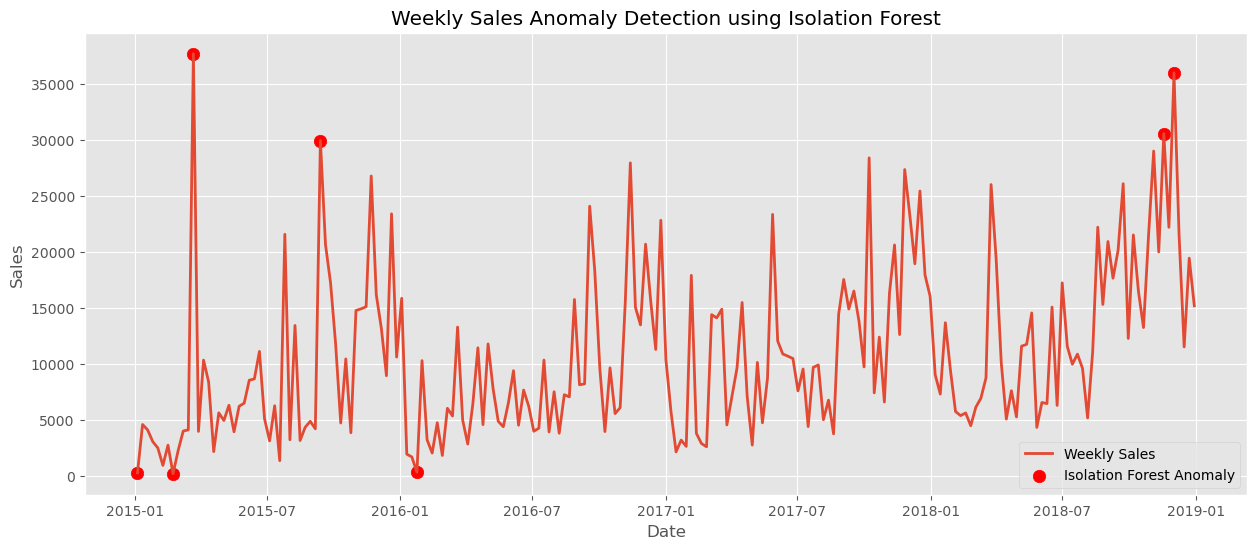

In [92]:
#Plot Isolation Forest Anomalies
plt.figure(figsize=(15,6))

# Weekly sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)

# Highlight anomalies

anomaly_points = weekly_sales[
    weekly_sales["IF_Anomaly"]=="Anomaly"
]

plt.scatter(
    anomaly_points["Order Date"],
    anomaly_points["Sales"],
    color="red",
    s=80,
    marker="o",
    label="Isolation Forest Anomaly"
)

plt.title("Weekly Sales Anomaly Detection using Isolation Forest")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/isolation_forest_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [93]:
anomaly_points

,Order Date,Sales,IF_Anomaly
0,2015-01-04,304.508,Anomaly
7,2015-02-22,224.912,Anomaly
11,2015-03-22,37703.665,Anomaly
36,2015-09-13,29959.137,Anomaly
55,2016-01-24,358.522,Anomaly
202,2018-11-18,30572.447,Anomaly
204,2018-12-02,35998.900,Anomaly


In [94]:
#Z-Score Based Detection

# Rolling statistics

weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
)

weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .std()
)

# Z-Score

weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling Mean"])
    / weekly_sales["Rolling Std"]
)

# Detect anomalies

weekly_sales["Z_Anomaly"] = np.where(
    weekly_sales["Z_Score"].abs() > 2,
    "Anomaly",
    "Normal"
)

weekly_sales.head()

,Order Date,Sales,IF_Anomaly,Rolling Mean,Rolling Std,Z_Score,Z_Anomaly
0,2015-01-04,304.508,Anomaly,NaN,NaN,NaN,Normal
1,2015-01-11,4619.108,Normal,NaN,NaN,NaN,Normal
2,2015-01-18,4130.533,Normal,NaN,NaN,NaN,Normal
3,2015-01-25,3092.544,Normal,3036.67325,1929.462566,0.028957,Normal
4,2015-02-01,2527.914,Normal,3592.52475,953.362968,-1.116690,Normal


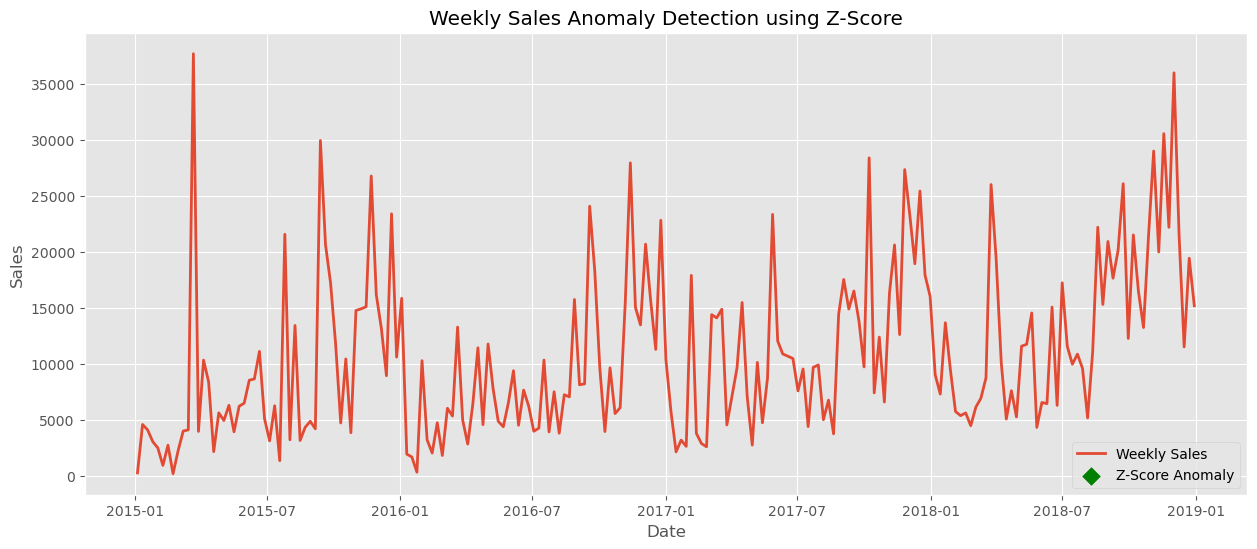

In [95]:
#Plot Z-Score Anomalies

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=2,
    label="Weekly Sales"
)

z_points = weekly_sales[
    weekly_sales["Z_Anomaly"]=="Anomaly"
]

plt.scatter(
    z_points["Order Date"],
    z_points["Sales"],
    color="green",
    marker="D",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales Anomaly Detection using Z-Score")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/zscore_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [96]:
#Compare Both Methods

comparison = weekly_sales[
    [
        "Order Date",
        "Sales",
        "IF_Anomaly",
        "Z_Anomaly"
    ]
]

comparison.head(15)

,Order Date,Sales,IF_Anomaly,Z_Anomaly
0,2015-01-04,304.508,Anomaly,Normal
1,2015-01-11,4619.108,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal
5,2015-02-08,968.534,Normal,Normal
6,2015-02-15,2771.054,Normal,Normal
7,2015-02-22,224.912,Anomaly,Normal
8,2015-03-01,2289.643,Normal,Normal
9,2015-03-08,4030.728,Normal,Normal


In [97]:
#Count Anomalies
print("Isolation Forest Anomalies:",
      (weekly_sales["IF_Anomaly"]=="Anomaly").sum())

print("Z-Score Anomalies:",
      (weekly_sales["Z_Anomaly"]=="Anomaly").sum())

Isolation Forest Anomalies: 7
Z-Score Anomalies: 0


In [98]:
#Common Anomalies
common = weekly_sales[
    (weekly_sales["IF_Anomaly"]=="Anomaly") &
    (weekly_sales["Z_Anomaly"]=="Anomaly")
]

common

,Order Date,Sales,IF_Anomaly,Rolling Mean,Rolling Std,Z_Score,Z_Anomaly


## Observations

Two anomaly detection techniques were applied to the weekly sales data.

### Isolation Forest
The Isolation Forest algorithm detected **7 anomalous weeks**. Since it is a machine learning–based approach, it identifies unusual observations by isolating data points that differ significantly from the overall sales pattern. These anomalies may represent festive sales, promotional campaigns, bulk customer orders, or unexpected changes in demand.

### Z-Score Method
The Z-Score method did **not detect any anomalies** using the threshold of ±2 standard deviations from the rolling mean. This indicates that the weekly sales fluctuations remained within the expected statistical range.

### Comparison of Both Methods
The two methods did **not identify the same anomalies**. Isolation Forest detected seven unusual weeks, while the Z-Score method detected none. This difference occurs because Isolation Forest considers the overall distribution and relationships within the data, whereas the Z-Score method only flags observations that exceed a predefined statistical threshold.

For this dataset, Isolation Forest proved to be more sensitive in detecting unusual sales behaviour than the Z-Score method.

# Task 6: Product Demand Segmentation using Clustering

The objective of this task is to segment product sub-categories into different demand groups using K-Means Clustering. The clustering is based on business-related features such as total sales volume, sales growth rate, sales volatility, and average order value. These demand groups help businesses optimize inventory planning and stocking strategies.

In [99]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [100]:
#Create Monthly Sales by Sub-Category

monthly_subcat = (
    df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="M")])["Sales"]
      .sum()
      .reset_index()
)

monthly_subcat.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [101]:
#Create Required Features
feature_df = monthly_subcat.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Sales_Volatility=("Sales", "std"),
    Average_Order_Value=("Sales", "mean")
).reset_index()

In [102]:
#Calculate Year-over-Year Growth
growth = []

for subcat in monthly_subcat["Sub-Category"].unique():

    temp = monthly_subcat[
        monthly_subcat["Sub-Category"] == subcat
    ].sort_values("Order Date")

    first = temp.iloc[:12]["Sales"].sum()
    last = temp.iloc[-12:]["Sales"].sum()

    if first == 0:
        rate = 0
    else:
        rate = ((last - first) / first) * 100

    growth.append(rate)

feature_df["Sales_Growth"] = growth

feature_df

,Sub-Category,Total_Sales,Sales_Volatility,Average_Order_Value,Sales_Growth
0,Accessories,164186.7000,2579.994809,3420.556250,145.055961
1,Appliances,104618.4030,1821.621539,2179.550062,165.242912
2,Art,26705.4100,330.488343,556.362708,49.649531
3,Binders,200028.7850,3848.223648,4167.266354,65.778638
4,Bookcases,113813.1987,2220.405080,2474.199972,37.464208
5,Chairs,322822.7310,4407.232960,6725.473563,20.954677
6,Copiers,146248.0940,5500.774391,4570.252938,236.142213
7,Envelopes,16128.0460,228.218688,350.609696,-12.519090
8,Fasteners,3001.9600,48.742229,63.871489,30.468364
9,Furnishings,89212.0180,1360.017867,1858.583708,106.824969


In [103]:
#Standardize Features
X = feature_df[
    [
        "Total_Sales",
        "Sales_Growth",
        "Sales_Volatility",
        "Average_Order_Value"
    ]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [104]:
#Elbow Method
wcss = []

for i in range(1, 8):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

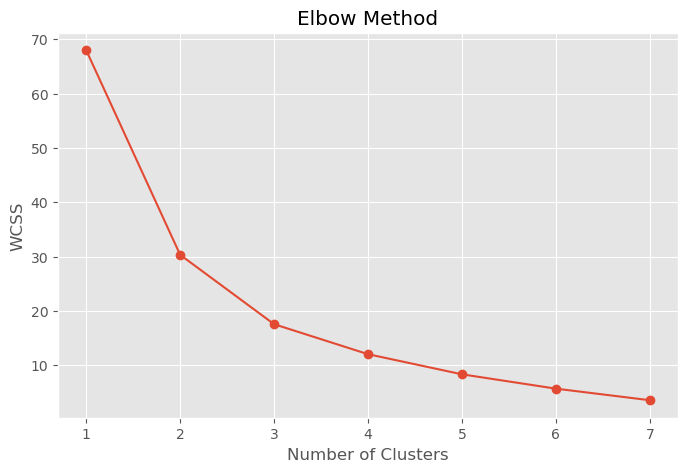

In [105]:
#Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(1,8),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [106]:
#Train Final K-Means Model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

feature_df["Cluster"] = kmeans.fit_predict(X_scaled)

feature_df.head()

,Sub-Category,Total_Sales,Sales_Volatility,Average_Order_Value,Sales_Growth,Cluster
0,Accessories,164186.7000,2579.994809,3420.556250,145.055961,2
1,Appliances,104618.4030,1821.621539,2179.550062,165.242912,2
2,Art,26705.4100,330.488343,556.362708,49.649531,0
3,Binders,200028.7850,3848.223648,4167.266354,65.778638,1
4,Bookcases,113813.1987,2220.405080,2474.199972,37.464208,2


In [107]:
#PCA for Visualization
pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

feature_df["PC1"] = components[:,0]
feature_df["PC2"] = components[:,1]

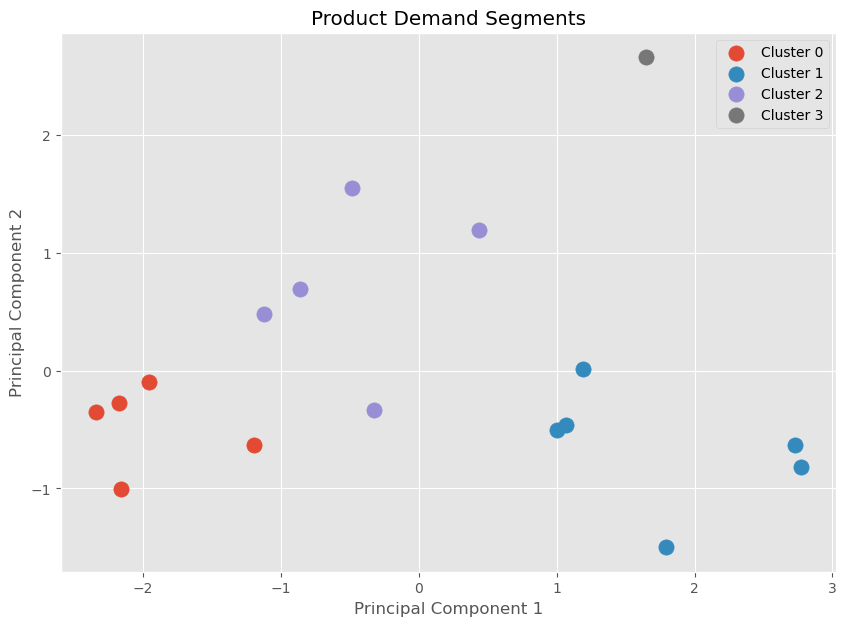

In [108]:
#Plot Clusters
plt.figure(figsize=(10,7))

for cluster in sorted(feature_df["Cluster"].unique()):

    subset = feature_df[
        feature_df["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=120,
        label=f"Cluster {cluster}"
    )

plt.title("Product Demand Segments")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [109]:
#View Cluster Members
feature_df[
    [
        "Sub-Category",
        "Cluster"
    ]
].sort_values("Cluster")

,Sub-Category,Cluster
8,Fasteners,0
2,Art,0
10,Labels,0
15,Supplies,0
7,Envelopes,0
14,Storage,1
13,Phones,1
11,Machines,1
16,Tables,1
5,Chairs,1


In [110]:
#Label the Clusters
feature_df.groupby("Cluster").mean(numeric_only=True)

,Total_Sales,Sales_Volatility,Average_Order_Value,Sales_Growth,PC1,PC2
Cluster,,,,,,
0,20920.69000,571.202923,456.619037,22.852390,-1.967352,-0.471722
1,243671.10250,3992.982732,5228.114821,25.390340,1.758555,-0.649347
2,109731.72474,1801.372855,2306.695932,109.298004,-0.472445,0.718203
3,146248.09400,5500.774391,4570.252938,236.142213,1.647656,2.663674


In [111]:
cluster_labels = {
    0: "Low Volume, Stable Demand",
    1: "High Volume, Stable Demand",
    2: "Growing Demand",
    3: "High Growth, High Volatility"
}

feature_df["Demand Segment"] = feature_df["Cluster"].map(cluster_labels)

feature_df[["Sub-Category", "Cluster", "Demand Segment"]].sort_values("Cluster")

,Sub-Category,Cluster,Demand Segment
8,Fasteners,0,"Low Volume, Stable Demand"
2,Art,0,"Low Volume, Stable Demand"
10,Labels,0,"Low Volume, Stable Demand"
15,Supplies,0,"Low Volume, Stable Demand"
7,Envelopes,0,"Low Volume, Stable Demand"
14,Storage,1,"High Volume, Stable Demand"
13,Phones,1,"High Volume, Stable Demand"
11,Machines,1,"High Volume, Stable Demand"
16,Tables,1,"High Volume, Stable Demand"
5,Chairs,1,"High Volume, Stable Demand"


## Product Demand Segmentation

K-Means clustering was applied to group product sub-categories based on total sales, sales growth, sales volatility, and average order value.

Four meaningful demand segments were identified:

- **High Volume, Stable Demand:** These products consistently generate high sales with predictable demand. They should be prioritized for inventory replenishment.
- **Growing Demand:** These products are experiencing strong growth and should be monitored closely to ensure sufficient stock availability.
- **High Growth, High Volatility:** These products have exceptional growth but also large fluctuations in demand. Inventory should be managed carefully with frequent monitoring and flexible replenishment.
- **Low Volume, Stable Demand:** These products contribute lower sales but maintain consistent demand. A lean inventory strategy is recommended to minimize holding costs.

Stocking Strategy Table

| Demand Segment                   | Recommended Stocking Strategy                                                          |
| -------------------------------- | -------------------------------------------------------------------------------------- |
| **High Volume, Stable Demand**   | Maintain high inventory levels and ensure continuous availability.                     |
| **Growing Demand**               | Increase stock gradually and monitor future demand closely.                            |
| **High Growth, High Volatility** | Keep safety stock, review inventory frequently, and respond quickly to demand changes. |
| **Low Volume, Stable Demand**    | Maintain minimal stock and use efficient inventory control to reduce holding costs.    |


## Conclusion

The clustering analysis identified four distinct demand segments among the product sub-categories. The **High Volume, Stable Demand** segment represents the most reliable products and should receive priority in inventory planning. The **High Growth, High Volatility** segment requires close monitoring due to rapid demand changes. Products in the **Growing Demand** segment offer future business opportunities, while **Low Volume, Stable Demand** products should be managed with lean inventory practices to optimize storage costs.

These demand-based segments provide valuable insights for improving inventory management, reducing stock-related risks, and supporting data-driven supply chain decisions.